# CBIS-DDSM Image Processing (Local)

## Dependency Setup

In [1]:
%pip install pydicom pandas numpy pillow tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Artemaius\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


## Imports

In [2]:
from pathlib import Path
import pandas as pd
import pydicom
import numpy as np
from PIL import Image
from tqdm import tqdm

## Settings

`DATA_ROOT` is the folder that contains the case folders (e.g. `Calc-Test_P_00038_LEFT_CC_1`) and the CSV files.

`PROCESSED_ROOT` is where the processed PNG images will be saved.

In [3]:
DATA_ROOT = Path("../../CBIS-DDSM/cbis_ddsm")

CSV_FILES = [
    (DATA_ROOT / "mass_case_description_train_set.csv", "train"),
    (DATA_ROOT / "mass_case_description_test_set.csv", "test"),
    (DATA_ROOT / "calc_case_description_train_set.csv", "train"),
    (DATA_ROOT / "calc_case_description_test_set.csv", "test"),
]

PROCESSED_ROOT = Path("Z:/My Drive/Databases/cbis_ddsm_processed")

OUTPUT_DIR_FULL = PROCESSED_ROOT / "cbis_ddsm_processed_full"
OUTPUT_DIR_ROI = PROCESSED_ROOT / "cbis_ddsm_processed_roi"

IMG_SIZE = (224, 224)

# None = process all patients
PATIENT_LIMIT = None


## Helper functions

In [4]:
def csv_path_to_dicom(csv_path):
    parts = Path(str(csv_path).strip().strip('"')).parts

    case = parts[0]
    uid1 = parts[1][-5:]
    uid2 = parts[2][-5:]

    folder = DATA_ROOT / case / uid1 / uid2

    dicoms = list(folder.glob("*.dcm"))

    if not dicoms:
        raise FileNotFoundError(f"DICOM folder not found or empty: {folder}")

    # Smallest file first
    dicoms.sort(key=lambda f: f.stat().st_size)

    return dicoms[0]


In [5]:
def load_dicom(path):
    
    ds = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)

    img -= img.min()
    if img.max() > 0:
        img /= img.max()

    img = (img * 255).astype(np.uint8)
    return img

In [6]:
def save_image(dicom_path, out_path):
    
    img = load_dicom(dicom_path)
    img = Image.fromarray(img)
    img = img.resize(IMG_SIZE, Image.Resampling.LANCZOS)

    img = np.array(img)

    Image.fromarray(img).save(out_path)

## CSV Headers: 

## Process the CSV files and save the images

In [7]:
def process_csv(csv_file, split, full_output_dir, roi_output_dir, stats):

    df = pd.read_csv(csv_file)

    # Normalize pathology labels
    df["pathology"] = df["pathology"].replace({
        "BENIGN_WITHOUT_CALLBACK": "BENIGN"
    })

    # Keep only the two target classes
    df = df[df["pathology"].isin(["BENIGN", "MALIGNANT"])].copy()

    full_image_labels = {}

    for full_raw_path, group in df.groupby("image file path"):

        # Clean path
        full_raw_path = str(full_raw_path).strip()
        full_raw_path = full_raw_path.strip('"').strip("'").strip()

        labels = set(group["pathology"].str.lower())

        if "malignant" in labels:
            full_label = "malignant"
        else:
            full_label = "benign"

        full_image_labels[full_raw_path] = {
            "label": full_label,
            "row": group.iloc[0]
        }

    print(
        f"Unique full mammograms in {csv_file.name}: "
        f"{len(full_image_labels)}"
    )

    # PROCESS FULL MAMMOGRAMS

    for full_raw_path, data in tqdm(
        full_image_labels.items(),
        desc=f"Full images ({split})"
    ):

        label = data["label"]
        row = data["row"]

        # Apply patient limit
        patient_number = int(row["patient_id"].split("_")[1])

        if PATIENT_LIMIT is not None and patient_number > PATIENT_LIMIT:
            continue

        abnormality = str(row["abnormality type"]).lower()

        if abnormality == "mass":
            abnormality_name = "Mass"

        elif abnormality == "calcification":
            abnormality_name = "Calc"

        else:
            continue

        full_out_dir = full_output_dir / split / label
        full_out_dir.mkdir(parents=True, exist_ok=True)

        full_filename = (
            f"{abnormality_name}_"
            f"{row['patient_id']}_"
            f"{row['left or right breast']}_"
            f"{row['image view']}.png"
        )

        full_out_path = full_out_dir / full_filename

        if full_out_path.exists():
            stats["already_exists"] += 1
            continue

        try:
            dicom_path = csv_path_to_dicom(full_raw_path)

            save_image(
                dicom_path,
                full_out_path
            )

            stats["processed"] += 1

        except Exception as e:

            print(
                f"[ERROR] {row['patient_id']} | "
                f"full | {type(e).__name__}: {e}"
            )

            stats["skipped"] += 1

            reason = f"Full: {type(e).__name__}"

            stats["skip_reasons"][reason] = (
                stats["skip_reasons"].get(reason, 0) + 1
            )

    # PROCESS ROI IMAGES

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"ROI images ({split})"
    ):

        patient_number = int(row["patient_id"].split("_")[1])

        if PATIENT_LIMIT is not None and patient_number > PATIENT_LIMIT:
            continue

        label = row["pathology"].lower()

        abnormality = str(row["abnormality type"]).lower()

        if abnormality == "mass":

            abnormality_name = "Mass"
            roi_column = "cropped image file path"

        elif abnormality == "calcification":

            abnormality_name = "Calc"
            roi_column = "ROI mask file path"

        else:
            continue

        # Clean ROI path

        roi_raw_path = str(row[roi_column]).strip()
        roi_raw_path = roi_raw_path.strip('"').strip("'").strip()

        # Output filename

        roi_out_dir = roi_output_dir / split / label
        roi_out_dir.mkdir(parents=True, exist_ok=True)

        roi_filename = (
            f"{abnormality_name}_"
            f"{row['patient_id']}_"
            f"{row['left or right breast']}_"
            f"{row['image view']}_"
            f"{row['abnormality id']}.png"
        )

        roi_out_path = roi_out_dir / roi_filename

        if roi_out_path.exists():
            stats["already_exists"] += 1
            continue

        # Convert ROI DICOM -> PNG

        try:

            dicom_path = csv_path_to_dicom(roi_raw_path)

            save_image(
                dicom_path,
                roi_out_path
            )

            stats["processed"] += 1

        except Exception as e:

            print(
                f"[ERROR] {row['patient_id']} | "
                f"roi | {type(e).__name__}: {e}"
            )

            stats["skipped"] += 1

            reason = f"ROI: {type(e).__name__}"

            stats["skip_reasons"][reason] = (
                stats["skip_reasons"].get(reason, 0) + 1
            )


In [8]:
stats = {
    "processed": 0,
    "skipped": 0,
    "already_exists": 0,
    "skip_reasons": {}
}

for csv_file, split in CSV_FILES:
    print(f"\nProcessing {csv_file.name} -> {split}")

    process_csv(
        csv_file,
        split,
        OUTPUT_DIR_FULL,
        OUTPUT_DIR_ROI,
        stats
    )

print("\nDONE")



Processing mass_case_description_train_set.csv -> train
Unique full mammograms in mass_case_description_train_set.csv: 1231


ROI images (train): 100%|██████████| 1318/1318 [00:40<00:00, 32.65it/s]



Processing mass_case_description_test_set.csv -> test
Unique full mammograms in mass_case_description_test_set.csv: 361


ROI images (test): 100%|██████████| 378/378 [00:05<00:00, 63.30it/s]



Processing calc_case_description_train_set.csv -> train
Unique full mammograms in calc_case_description_train_set.csv: 1227


...

[ERROR] P_01460 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01460_RIGHT_CC_1\05607\95643
[ERROR] P_01460 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01460_RIGHT_MLO_1\44828\45707
[ERROR] P_01471 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01471_RIGHT_CC_1\94984\23185
[ERROR] P_01471 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01471_RIGHT_MLO_1\33113\56217
[ERROR] P_01476 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01476_RIGHT_CC_1\00079\41234
[ERROR] P_01483 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01483_LEFT_MLO_1\23303\25756
[ERROR] P_01502 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01502_LEFT_CC_2\03761\8037

ROI images (test):  92%|█████████▏| 300/326 [00:01<00:00, 182.23it/s]

[ERROR] P_01713 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01713_RIGHT_MLO_1\71032\28974
[ERROR] P_01728 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01728_LEFT_CC_1\17979\14184
[ERROR] P_01752 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01752_LEFT_MLO_1\45016\09916
[ERROR] P_01773 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01773_RIGHT_CC_1\38525\32845
[ERROR] P_01820 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01820_LEFT_MLO_1\54721\82999
[ERROR] P_01842 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01842_LEFT_MLO_1\84824\56596
[ERROR] P_01845 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_01845_RIGHT_CC_1\29648\19666

ROI images (test): 100%|██████████| 326/326 [00:01<00:00, 179.17it/s]

[ERROR] P_02176 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_02176_RIGHT_CC_1\96266\81115
[ERROR] P_02176 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_02176_RIGHT_MLO_1\38095\34408
[ERROR] P_02275 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_02275_LEFT_CC_1\76585\62451
[ERROR] P_02418 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_02418_RIGHT_CC_1\85568\26873
[ERROR] P_02420 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_02420_RIGHT_CC_1\79029\73626
[ERROR] P_02420 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_02420_RIGHT_MLO_1\73377\29466
[ERROR] P_02432 | roi | FileNotFoundError: DICOM folder not found or empty: ..\..\CBIS-DDSM\cbis_ddsm\Calc-Test_P_02432_LEFT_CC_1\83523\78407

In [9]:
def print_summary(name, stats):
    print(f"\n--- {name} ---")
    print(f"Newly processed: {stats['processed']}")
    print(f"Already existed: {stats['already_exists']}")
    print(f"Failed/skipped:  {stats['skipped']}")

    if stats["skip_reasons"]:
        print("Skip reasons:")
        for reason, count in sorted(
            stats["skip_reasons"].items(),
            key=lambda x: -x[1]
        ):
            print(f"  {count}x  {reason}")


print_summary("Full + ROI", stats)



--- Full + ROI ---
Newly processed: 6268
Already existed: 0
Failed/skipped:  403
Skip reasons:
  246x  Full: FileNotFoundError
  157x  ROI: FileNotFoundError


In [10]:
def count_processed_images(output_dir):
    """Count all .png files under a processed dataset folder, broken down by split/label."""
    counts = {}
    total = 0

    for split in ["train", "test"]:
        for label in ["benign", "malignant"]:
            folder = output_dir / split / label
            n = len(list(folder.glob("*.png"))) if folder.exists() else 0
            counts[f"{split}/{label}"] = n
            total += n

    counts["total"] = total
    return counts

In [11]:
# After processing - both datasets
roi_counts = count_processed_images(OUTPUT_DIR_ROI)
full_counts = count_processed_images(OUTPUT_DIR_FULL)

print("\n--- Cropped ROI dataset ---")
for key, value in roi_counts.items():
    print(f"{key}: {value}")

print("\n--- Full mammogram dataset ---")
for key, value in full_counts.items():
    print(f"{key}: {value}")


--- Cropped ROI dataset ---
train/benign: 1683
train/malignant: 1181
test/benign: 330
test/malignant: 217
total: 3411

--- Full mammogram dataset ---
train/benign: 1347
train/malignant: 1111
test/benign: 233
test/malignant: 166
total: 2857


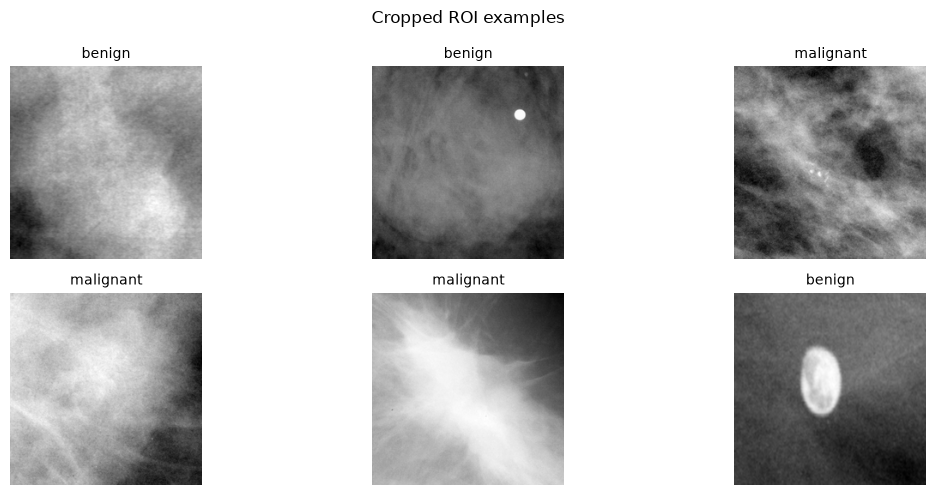

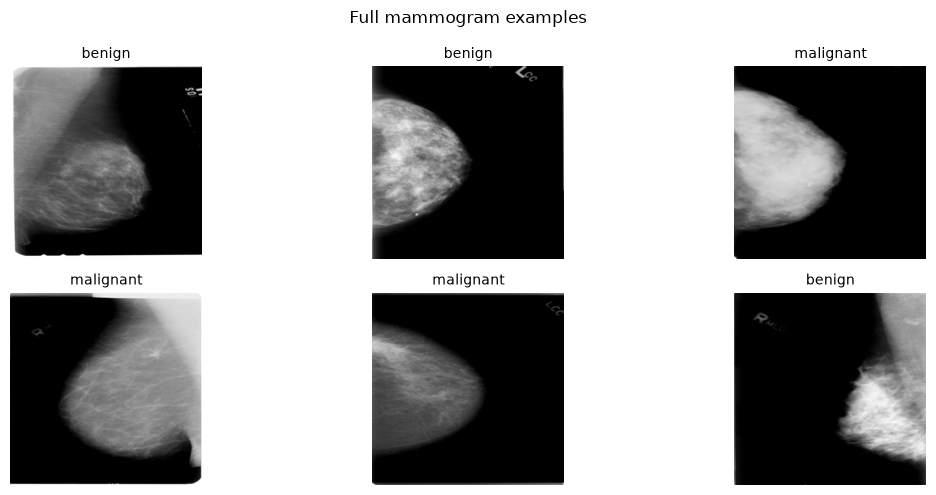

In [12]:
import matplotlib.pyplot as plt
import random

def show_examples(output_dir, title, n=6):
    # Show n random example images from a processed dataset folder.

    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 5))
    axes = axes.flatten()

    # Gather a few images from each class so both are represented
    image_paths = []
    for label in ["benign", "malignant"]:
        folder = output_dir / "train" / label
        files = list(folder.glob("*.png"))
        random.shuffle(files)
        image_paths.extend([(f, label) for f in files[: n // 2]])

    random.shuffle(image_paths)

    for ax, (path, label) in zip(axes, image_paths):
        img = Image.open(path)
        ax.imshow(img, cmap = "gray")
        ax.set_title(label, fontsize=10)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(OUTPUT_DIR_ROI, "Cropped ROI examples")
show_examples(OUTPUT_DIR_FULL, "Full mammogram examples")